# NLP ШИФТ — классификация интента последнего сообщения пользователя

## Задача
1) Создать синтетический набор данных банковских диалогов с помощью LLM
   (У меня 1500 примеров, 15 классов × 100)
2) Обучить трансформерную модель-энкодер (BERT) для классификации **последней
   реплики пользователя** в диалоге поддержки банка.

## Структура ноутбука (Часть 1)
1. рассказ как генерил данные

## Структура ноутбука (Часть 2)
1. Загрузка и парсинг
2. EDA
3. Подготовка датасета
4. обучение
5. Оценка
6. Сохранение
6. Демо-инференс



# Часть 1 (Генерация синтетики)

Синтетический датасет был предварительно сгенерирован с помощью локальной LLM Qwen2.5-14B-Instruct через OpenAI-compatible API. Генерация выполнялась отдельным Python-скриптом generate_data.py в VS Code

Датасет содержит 1500 диалогов: 15 классов по 100 примеров

Вот такой скрипт:

In [ ]:
# import json
# import argparse
# from pathlib import Path
# from dataclasses import dataclass
# from openai import OpenAI
# from pydantic import BaseModel, ConfigDict, Field
# from tqdm import tqdm

# TAXONOMY = {
#     "transfer_status": "Статус или задержка денежного перевода.",
#     "card_block": "Срочная блокировка карты (потеря, кража, мошенничество).",
#     "loan_early_repayment": "Досрочное или частичное погашение кредита.",
#     "app_error": "Сбои и ошибки в мобильном приложении или интернет-банке.",
#     "card_order": "Заказ новой или дополнительной карты и сроки доставки.",
#     "loan_application": "Оформление заявки на кредит и условия.",
#     "atm_location": "Поиск банкоматов и отделений банка.",
#     "balance_info": "Запрос остатка на счёте или карте.",
#     "transaction_history": "История операций и выписка по счёту.",
#     "pin_change": "Смена или восстановление ПИН-кода.",
#     "theft_report": "Сообщение о мошеннических списаниях.",
#     "currency_exchange": "Курсы валют и комиссии за конвертацию.",
#     "sbp_payment_issue": "Проблемы при переводах и оплате через СБП.",
#     "card_reissue": "Перевыпуск карты по истечении срока.",
#     "feedback_complaint": "Отзывы и жалобы на работу банка.",
# }

# class DialogExample(BaseModel):
#     model_config = ConfigDict(extra="forbid")
#     label: str = Field(description="Имя класса интента строго из таксономии.")
#     dialog: str = Field(description="Диалог из 3 реплик: user, assistant, user.")

# class BatchResponse(BaseModel):
#     model_config = ConfigDict(extra="forbid")
#     dialogs: list[DialogExample]

# @dataclass
# class EngineConfig:
#     base_url: str
#     model: str
#     examples_per_class: int = 100
#     batch_size: int = 10
#     output_path: Path = Path("synthetic_dataset.jsonl")

# SYSTEM_PROMPT = (
#     "Ты — генератор синтетических диалогов банковской поддержки для обучения классификатора. "
#     "Пользователи пишут по-русски, ассистент — вежливый сотрудник банка. Отвечай строго JSON-объектом."
# )

# USER_PROMPT_TEMPLATE = """Сгенерируй {n} разных примеров диалогов для класса "{label}".
# Описание: {description}

# Правила для каждого диалога:
# 1) Ровно 3 реплики на отдельных строках:
# user: <вопрос>
# assistant: <ответ сотрудника>
# user: <целевой вопрос про {label}>
# 2) Последняя реплика — всегда вопрос пользователя.

# Верни JSON: {{"dialogs": [{{"label": "{label}", "dialog": "user: ...\\nassistant: ...\\nuser: ..."}}]}}"""

# def validate_example(label: str, dialog: str) -> bool:
#     if label not in TAXONOMY:
#         return False
#     lines = [l.strip() for l in dialog.split("\n") if l.strip()]
#     if len(lines) != 3:
#         return False
#     return lines[0].startswith("user:") and lines[1].startswith("assistant:") and lines[2].startswith("user:")

# def request_batch(client: OpenAI, cfg: EngineConfig, label: str, n: int) -> list[DialogExample]:
#     response = client.chat.completions.create(
#         model=cfg.model,
#         messages=[
#             {"role": "system", "content": SYSTEM_PROMPT},
#             {"role": "user", "content": USER_PROMPT_TEMPLATE.format(n=n, label=label, description=TAXONOMY[label])}
#         ],
#         response_format={"type": "json_object"},
#         temperature=0.8
#     )
#     data = json.loads(response.choices[0].message.content)
#     return [DialogExample.model_validate(item) for item in data.get("dialogs", [])]

# def main():
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--base-url", default="http://localhost:8081/v1")
#     parser.add_argument("--model", default="qwen2.5-14b")
#     parser.add_argument("--output", default="synthetic_dataset.jsonl")
#     args = parser.parse_args()

#     cfg = EngineConfig(base_url=args.base_url, model=args.model, output_path=Path(args.output))
#     client = OpenAI(base_url=cfg.base_url, api_key="not-needed")

#     with cfg.output_path.open("w", encoding="utf-8") as f:
#         for label in tqdm(TAXONOMY, desc="Генерация классов"):
#             written = 0
#             while written < cfg.examples_per_class:
#                 n = min(cfg.batch_size, cfg.examples_per_class - written)
#                 try:
#                     examples = request_batch(client, cfg, label, n)
#                     for ex in examples:
#                         if ex.label == label and validate_example(ex.label, ex.dialog):
#                             f.write(json.dumps(ex.model_dump(), ensure_ascii=False) + "\n")
#                             written += 1
#                 except Exception:
#                     continue
#     print(f"Готово! Датасет сохранен в {cfg.output_path}")

# if __name__ == "__main__":
#     main()

А сервер подымал в llama-server, через такой скрипт:

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# model_path = "/content/drive/MyDrive/LLM_Models/qwen2.5-14b-instruct-q4_k_m.gguf"
# assert os.path.exists(model_path), "Файл модели не найден на диске!"
# print("Модель найдена:", model_path)

# Быстрая компиляция llama.cpp с поддержкой GPU
# !git clone https://github.com/ggerganov/llama.cpp 2>/dev/null || true
# !cmake -B llama.cpp/build -DGGML_CUDA=ON >/dev/null && cmake --build llama.cpp/build --config Release -j2 >/dev/null
# print("llama.cpp скомпилирован!")

# Фоновый запуск llama-server и туннеля Cloudflare для доступа по API
# import subprocess, time, re, urllib.request

# server_process = subprocess.Popen([
#     "./llama.cpp/build/bin/llama-server",
#     "-m", model_path, "-c", "4096", "--port", "8081", "-ngl", "99"
# ], stdout=open("/dev/null", "w"), stderr=subprocess.STDOUT)

# # Ждем старта сервера
# for _ in range(30):
#     try:
#         if urllib.request.urlopen("http://127.0.0.1:8081/v1/models").status == 200:
#             break
#     except:
#         time.sleep(1)

# # Запускаем cloudflared туннель
# !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared && chmod +x cloudflared
# tunnel_process = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://127.0.0.1:8081"], stdout=open("tunnel.log", "w"), stderr=subprocess.STDOUT)

# time.sleep(5)
# with open("tunnel.log") as f:
#     url = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', f.read()).group(0)

# print(f"API запущен! Endpoint: {url}/v1")

# Часть 2 (Классификация)

## 0. зависимости и импорты


In [22]:
!pip install -q transformers datasets

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)

DATA_PATH = Path("/content/drive/MyDrive/NLP_Shift_Training/synthetic_dataset.jsonl")

# Пока оставлю потом удалю
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Внешний вид графиков
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

## 1. Загрузка и парсинг данных

- Читаем `synthetic_dataset.jsonl`
- Из каждого диалога извлекаем **только последнюю реплику пользователя**


| Класс | Интент |
|---|---|
| `transfer_status` | статус перевода |
| `card_block` | блокировка карты |
| `loan_early_repayment` | досрочное погашение кредита |
| `app_error` | ошибка мобильного приложения |
| `card_order` | заказ карты |
| `loan_application` | заявка на кредит |
| `atm_location` | поиск банкомата |
| `balance_info` | информация о балансе |
| `transaction_history` | история операций |
| `pin_change` | изменение PIN-кода |
| `theft_report` | сообщение о краже/несанкционированной ситуации |
| `currency_exchange` | обмен валюты |
| `sbp_payment_issue` | проблема с платежом через СБП |
| `card_reissue` | перевыпуск карты |
| `feedback_complaint` | отзыв или жалоба |

In [24]:
df = pd.read_json(DATA_PATH, lines=True)

def extract_last_user_text(dialog):
  """Простая функция извлечения текста"""
  last_line = dialog.strip().split('\n')[-1]
  return last_line.split(':', 1)[-1].strip()

df["text"] = df["dialog"].apply(extract_last_user_text)

print(f"Загружено примеров: {len(df)}")

# проверка на случайном примере
sample = df.sample(1).iloc[0]
print("-" * 50)
print(f"LABEL: {sample['label']}")
print(f"DIALOG:\n{sample['dialog']}")
print(f"TEXT (вход классификатора): '{sample['text']}'")
print("-" * 50)

df[["label", "text"]].head()

Загружено примеров: 1500
--------------------------------------------------
LABEL: currency_exchange
DIALOG:
user: Здравствуйте, подскажите, пожалуйста, можно ли перевести деньги на карту другого банка?
assistant: Да, можно, но уточните комиссию.
user: А сколько будет стоить конвертация на 1000 долларов?
TEXT (вход классификатора): 'А сколько будет стоить конвертация на 1000 долларов?'
--------------------------------------------------


,label,text
0,transfer_status,Когда он придет?
1,transfer_status,А когда же он зачислится?
2,transfer_status,Когда можно ждать поступления?
3,transfer_status,"А вы можете сказать, когда он придет?"
4,transfer_status,Когда же он придет?


In [25]:
for i in range(3):
    row = df.iloc[i]
    print("LABEL:", row["label"])
    print("DIALOG:\n", row["dialog"])
    print("TEXT:", repr(row["text"]))
    print("-" * 70)


LABEL: transfer_status
DIALOG:
 user: Здравствуйте, у меня перевод на карту был, а денег нет уже 2 дня
assistant: Спасибо за обращение, давайте проверим статус
user: Когда он придет?
TEXT: 'Когда он придет?'
----------------------------------------------------------------------
LABEL: transfer_status
DIALOG:
 user: Добрый день, подскажите пожалуйста, я отправил деньги на карту вчера, а до сих пор их нет
assistant: Конечно, сейчас проверю
user: А когда же он зачислится?
TEXT: 'А когда же он зачислится?'
----------------------------------------------------------------------
LABEL: transfer_status
DIALOG:
 user: Привет, я отправил деньги на карту другу вчера, а он говорит что пока их нет
assistant: Понял, давайте проверим статус перевода
user: Когда можно ждать поступления?
TEXT: 'Когда можно ждать поступления?'
----------------------------------------------------------------------


## 2. EDA


In [26]:
# пример для кажд.класса
for label, group in df.groupby("label"):
    print(f"### {label}")
    print(group.sample(1)["dialog"].values[0], "\n")

### app_error
user: Добрый вечер, скажите, как оплатить коммунальные услуги через интернет-банк?
assistant: В разделе "Оплата услуг" выберите опцию "Коммунальные услуги"
user: А если у меня ошибка, приложение вылетает, что делать? 

### atm_location
user: Здравствуйте, скажите пожалуйста, куда можно отправить денежные переводы?
assistant: Денежные переводы можно отправить на любую карту или счет.
user: А как найти ближайший банкомат, где можно отправить перевод? 

### balance_info
user: Добрый день, можно узнать, когда будет доступен транзакционный отчет?
assistant: Отчет будет доступен уже сегодня вечером.
user: А сколько на счету сейчас? 

### card_block
user: Добрый день, есть ли в вашем банке кешбэк на бензин?
assistant: Да, есть, но условия программы могут меняться.
user: Я нашел подозрительные транзакции, как заблокировать карту? 

### card_order
user: Добрый день, я хотел бы узнать, можно ли заказать дополнительную карту к основной?
assistant: Да, конечно, вы можете заказать доп

In [27]:
# Пример по 2шт
for label in sorted(df["label"].unique()):
    rows = df[df["label"] == label].head(2)
    for _, row in rows.iterrows():
        print(f"### {label}")
        print(row["dialog"])
        print()


### app_error
user: Привет, как погода в Москве сегодня?
assistant: Погода переменная, в основном дождик.
user: А можно узнать, почему приложение не открывается?

### app_error
user: Добрый день, как дела?
assistant: Здравствуйте, у меня все хорошо, спасибо.
user: А у меня проблема, не могу войти в приложение.

### atm_location
user: Добрый день, когда начнут работать новые банкоматы в торговом центре?
assistant: Здравствуйте, они уже работают.
user: А где именно они находятся в торговом центре?

### atm_location
user: Привет, у меня вопрос о комиссии за снятие наличных.
assistant: Здравствуйте, комиссия составляет 1% от суммы.
user: А у вас есть ближайший банкомат без комиссии?

### balance_info
user: Здравствуйте, мне нужно будет до конца месяца оплатить коммунальные услуги.
assistant: Конечно, я помогу вам.
user: Сколько у меня денег на карте, чтобы я мог всё рассчитать?

### balance_info
user: Добрый день, я слышал, что банк проводит акцию, связана ли она с покупками?
assistant: Да

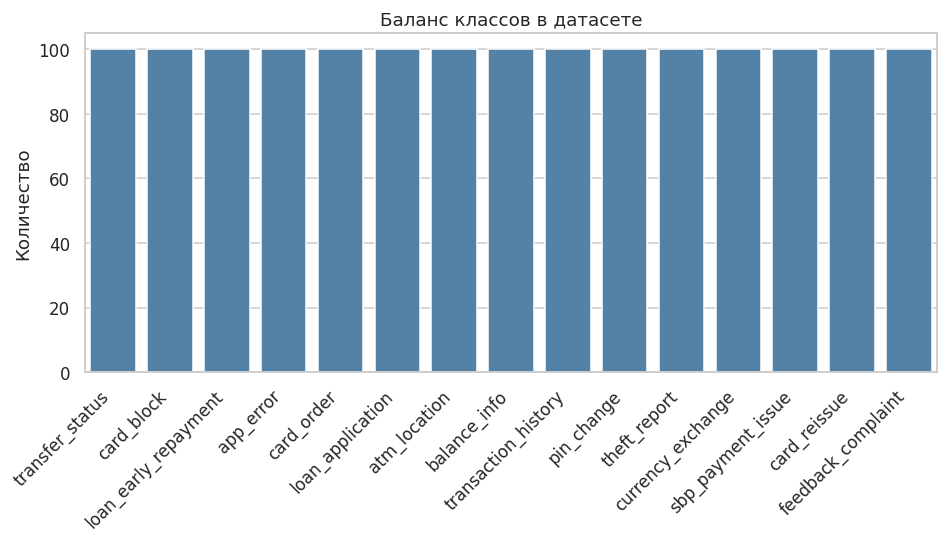

Всего классов: 15 | Примеров на класс: 100


In [28]:
# Баланс классов
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="label", color="steelblue")

plt.title("Баланс классов в датасете")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Количество")
plt.xlabel("")
plt.show()

print(f"Всего классов: {df['label'].nunique()} | Примеров на класс: {df['label'].value_counts().min()}")

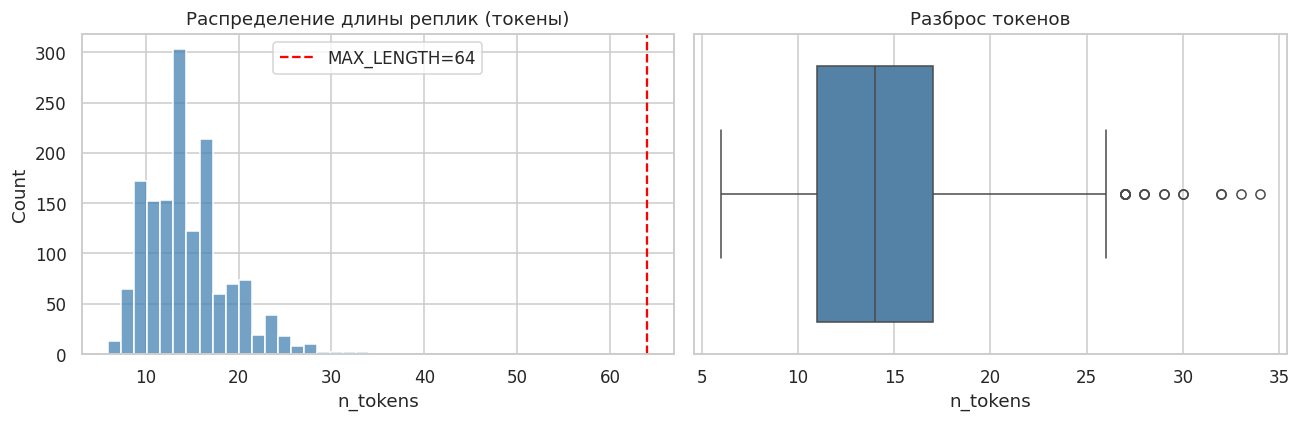

Статистика длины (токены):
50%    14.0
95%    23.0
99%    27.0
max    34.0
Name: n_tokens, dtype: float64


In [29]:
MODEL_CHECKPOINT = "ai-forever/ruBert-base"
MAX_LENGTH = 64

# Токенизируем только нашу целевую колонку text
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
df["n_tokens"] = df["text"].apply(lambda t: len(tokenizer.encode(t)))

# графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["n_tokens"], bins=20, ax=ax1, color="steelblue")
ax1.axvline(MAX_LENGTH, color="red", ls="--", label=f"MAX_LENGTH={MAX_LENGTH}")
ax1.set_title("Распределение длины реплик (токены)")
ax1.legend()

sns.boxplot(x=df["n_tokens"], ax=ax2, color="steelblue")
ax2.set_title("Разброс токенов")

plt.tight_layout()
plt.show()

print("Статистика длины (токены):")
print(df["n_tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(1)[['50%', '95%', '99%', 'max']])

## 3. Подготовка датасета: сплит и токенизация


In [30]:
# Автоматический маппинг классов
labels = sorted(df["label"].unique())
label2id = {name: i for i, name in enumerate(labels)}
id2label = {i: name for name, i in label2id.items()}

df["labels"] = df["label"].map(label2id)

# сплит
train_df, test_df = train_test_split(
    df[["text", "labels"]], test_size=0.2, random_state=RANDOM_SEED, stratify=df["labels"]
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 300
    })
})


In [31]:
# Токенизация
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

dataset = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

sample = dataset["train"][0]
print(f"Декодированный вход: {tokenizer.decode(sample['input_ids'])}")
print(f"Истинный класс: {id2label[sample['labels']]}")

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Декодированный вход: [CLS] мне никто не объяснил никаких условии, просто отмахнулись. [SEP]
Истинный класс: feedback_complaint


## 4. обучение


In [32]:
# Функция подсчета метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# Загрузка базовой модели с новой "головой" на 15 классов
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="results/checkpoints",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=RANDOM_SEED
)

# запуск
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params we

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.256451,1.117547,0.953333,0.952683
2,0.591602,0.421595,0.950000,0.949918
3,0.303361,0.233450,0.960000,0.960465
4,0.129107,0.183459,0.963333,0.963787
5,0.101445,0.174325,0.960000,0.960465


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.641657958984375, metrics={'train_runtime': 407.2186, 'train_samples_per_second': 14.734, 'train_steps_per_second': 0.921, 'total_flos': 71862371697888.0, 'train_loss': 0.641657958984375, 'epoch': 5.0})

## 5. Оценка на тесте

                      precision    recall  f1-score   support

           app_error      1.000     0.950     0.974        20
        atm_location      0.909     1.000     0.952        20
        balance_info      1.000     1.000     1.000        20
          card_block      0.900     0.900     0.900        20
          card_order      0.905     0.950     0.927        20
        card_reissue      1.000     0.950     0.974        20
   currency_exchange      1.000     0.950     0.974        20
  feedback_complaint      0.950     0.950     0.950        20
    loan_application      1.000     1.000     1.000        20
loan_early_repayment      1.000     1.000     1.000        20
          pin_change      1.000     0.900     0.947        20
   sbp_payment_issue      1.000     1.000     1.000        20
        theft_report      0.818     0.900     0.857        20
 transaction_history      1.000     1.000     1.000        20
     transfer_status      1.000     1.000     1.000        20

      

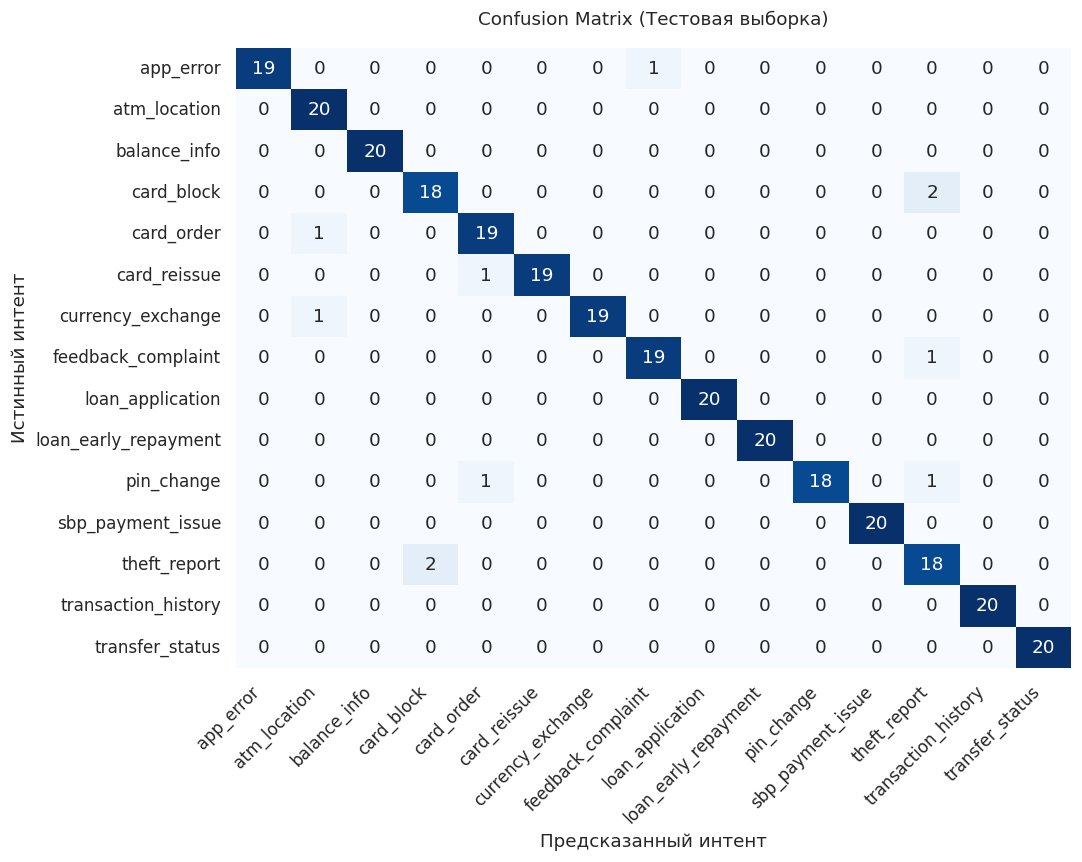

In [33]:
# Получаем предсказания модели на тесте
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

class_names = list(label2id.keys())

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# матрица ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix (Тестовая выборка)", pad=15)
plt.ylabel("Истинный интент")
plt.xlabel("Предсказанный интент")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Сохранение обученной модели



In [34]:
SAVE_PATH = "results/final_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Модель и токенизатор успешно сохранены в {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель и токенизатор успешно сохранены в results/final_model


## 7. Демо-инференс: используем сохранённую модель

Проверка на своих фразах и на случайных тестовых диалогах, включая подачу
диалога целиком


In [35]:
from transformers import pipeline

# Загружаем сохраненную модель
classifier = pipeline(
    "text-classification",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)

demo_texts = [
    "Я вчера отправил перевод, а деньги всё ещё не пришли. Когда зачислится братан?",
    "Срочно заблокируйте мою карту, я её потерял на Томской экскурсии Тбанка по офису.",
    "У меня списали деньги за подписку CODEX, которую я не оформлял!"
]

print("Демонстрация работы модели:\n" + "-"*60)
for text in demo_texts:
    pred = classifier(text)[0]
    print(f"Текст:  {text}")
    print(f"Интент: {pred['label']} (уверенность: {pred['score']:.2f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Демонстрация работы модели:
------------------------------------------------------------
Текст:  Я вчера отправил перевод, а деньги всё ещё не пришли. Когда зачислится братан?
Интент: transfer_status (уверенность: 0.90)

Текст:  Срочно заблокируйте мою карту, я её потерял на Томской экскурсии Тбанка по офису.
Интент: card_block (уверенность: 0.92)

Текст:  У меня списали деньги за подписку CODEX, которую я не оформлял!
Интент: theft_report (уверенность: 0.85)

